# Case 1

# How do the models behave on clean data?

## Purpose of this notebook

This notebook demonstrates one of the central findings of the thesis:

> A well-calibrated model should start the test stream with a low false-positive rate. Transformer-VAE instead fits the warmup window so tightly that its rolling threshold starts miscalibrated, producing an early false-positive burst before it adapts.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **clean data** — no anomalies are injected, so every predicted 'anomaly' is by definition a false positive. This isolates each architecture's baseline calibration behavior from detection difficulty.

---

## What is being compared?

The notebook runs four variants:

| Variant | Architecture | Meaning |
|---|---|---|
| **MLP-VAE** | Feed-forward VAE, plain (no cyclic reconstruction) | thesis_code's baseline MLP — no explicit calendar-phase signal in the loss. |
| **MLP-VAE-Cyclic** | Feed-forward VAE, cyclic time features reconstructed | The thesis found this stays calibrated from the very first test-stream step. |
| **LSTM-VAE** | Recurrent VAE | Sits between the MLP and Transformer variants in capacity. |
| **Transformer-VAE** | Attention-based VAE | The thesis found this overfits the warmup window and produces an early false-positive burst before its rolling threshold adapts. |

All four variants are trained on the same warmup window with the same window-mode streaming and rolling-threshold settings — the only difference is the encoder/decoder architecture.

## Thesis result being illustrated

The thesis found that Transformer-VAE's higher capacity lets it fit the warmup data extremely tightly, so its rolling anomaly-score threshold starts out miscalibrated and produces a burst of false positives before adapting to the true data distribution. MLP-VAE-Cyclic, with its simpler architecture, does not overfit the warmup window the same way and stays calibrated from the start.

This notebook runs on the full-scale real ERA5 export (755,568 rows, warmup_end=302227, no `stream.max_steps` cap) — the same warmup/test split thesis_code uses for this experiment. Earlier testing on a shorter 12-year slice showed the *opposite* FP ordering (Transformer-VAE calibrating better than MLP-Cyclic); slicing thesis_code's own run down to a matching window count confirmed the early-burst effect is already fully present after a long warmup, so matching warmup length — not just window count — is what reproduces the thesis's qualitative result. Exact metric values are still not guaranteed to match the thesis exactly (single seed, this repo's own port of the training code), but the **relative pattern between the four architectures** should now be directly comparable.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run all four architecture variants on the same full-scale clean ERA5 export.
4. Collect false-positive counts and compute the false-positive rate per architecture.
5. Compare the four architectures' calibration directly.

### Expected runtime

All four variants use window-mode streaming on GPU. On the full-scale export, each run trains on ~34.5 years of warmup and streams ~51.7 years of test data — expect roughly 3–15 minutes per architecture depending on model size (Transformer is the slowest). With 2 GPU slots the suite runs two variants at a time, so expect ~2 rounds — roughly 15–30 minutes total, not the under-a-minute runtime of the mini-dataset version.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [5]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.10.0+cu126
CUDA available: True
Selected device: NVIDIA RTX 6000 Ada Generation


### Import and/or load Repo

In [6]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /home/cohenhada/streaming-vae-anomaly-detection
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Step 1 — Run the four experiment variants

In [ ]:
CASE_ID = "case01_clean_baseline"
SESSION_DIR = "runs/regression_cuda-small1"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

#### Configuration file

The suite configuration is stored in:

```text
notebooks/cases/case01_clean_baseline_suite.yaml
```

It combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, and stream mode settings for each run — MLP-VAE-Cyclic layers in cyclic time-feature reconstruction; the plain MLP, LSTM, and Transformer-VAE variants do not.

All four variants use the same base configuration, the same full-scale ERA5 export, and the same evaluation procedure. The intended comparison is therefore the effect of **architecture choice on baseline false-positive calibration**.

#### Output Directory

During execution, the script creates a separate run directory for each variant under:

```text
runs/regression/case01_clean_baseline/
```

You may see detailed training output below. The final comparison is presented after all four runs finish.

`notebooks/cases/case01_clean_baseline_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode fragments for each of the runs below (see the suite file for the exact overrides). Runs execute in parallel across available GPU slots, two at a time here.

#### Expected output

The command below trains and evaluates each configured variant. Successful completion should produce four run folders containing predictions, metrics, and diagnostic outputs.

### Command:

In [8]:
!python run_regression.py notebooks/cases/{CASE_ID}_suite.yaml \
    --session {SESSION_DIR} --gpus 1

[suite] log     : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression_cuda22/suite.log
[suite] suite   : /home/cohenhada/streaming-vae-anomaly-detection/notebooks/cases/case01_clean_baseline_suite.yaml
[suite] session : /home/cohenhada/streaming-vae-anomaly-detection/runs/regression_cuda22
[suite] base cfg: /home/cohenhada/streaming-vae-anomaly-detection/notebooks/cases/../../modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [1]  (1 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite]  (module: regression.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite]  (module: regression.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite]  (module: regression.run_trial)
  [  4] TF_VAE_Clean  [case01_clean_baseline/case01_clean_baseline_suite]  (module: regression.run_trial)
[suite] START  'MLP_Clean'  (GPU=1)
GLOBAL SEED = 49
Logger: 

### Step 2 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table;
- anomaly-score histograms;
- an F1 comparison across variants;
- confusion-matrix summaries; and
- seed-stability diagnostics, where applicable.

These outputs are saved under:

```text
runs/regression/case01_clean_baseline/cross_compare/
```

### Command:

In [9]:
!python cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression_cuda22/case01_clean_baseline
[cross] output  : runs/regression_cuda22/case01_clean_baseline/cross_compare
[cross] 4 run(s) found:
  LSTM_Clean_LSTM                                     arch=LSTM  anomaly=Clean  cyclic=False  mode=window
  MLP_Clean_MLP                                       arch=MLP  anomaly=Clean  cyclic=False  mode=window
  MLP_Cyclic_Clean_MLP_Cyclic                         arch=MLP_Cyclic  anomaly=Clean  cyclic=False  mode=window
  TF_VAE_Clean_TF_VAE                                 arch=TF_VAE  anomaly=Clean  cyclic=False  mode=window

[cross] Loading run data ...
  LSTM_Clean_LSTM ... ok
  MLP_Clean_MLP ... ok
  MLP_Cyclic_Clean_MLP_Cyclic ... ok
  TF_VAE_Clean_TF_VAE ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Clean anomalies ═══════════════════════════════════════════════════════════════════════════════════════════════
  run_name                                     arch 

### Step 3 — Inspect the numerical results

#### Focus first on the `fp` and `accuracy` columns — F1, AUC, precision, and recall are undefined here (`NaN`) since every sample is labelled normal and no true positives exist to compute them against:

- `accuracy` is `1 - FPR`: the fraction of normal samples correctly left unflagged;
- `fp` is the raw false-positive count — the metric the thesis actually compares;
- `tp`, `tn`, and `fn` are provided for completeness (`tp` and `fn` are always 0 here).

#### Expected qualitative pattern

thesis_code's own full-scale run (`v7`, seed 49) gives this false-positive ordering, lowest to highest:

```text
MLP-VAE-Cyclic  <  MLP-VAE  <  LSTM-VAE  <  Transformer-VAE
     206              275         454           834
```

An early miscalibration burst for Transformer-VAE (90% of its false positives land in the first 23% of the stream) vs. calibrated-from-the-start behavior for MLP-VAE-Cyclic. This testcase is successful when that direction holds, even if the exact counts differ from the thesis.

### Command:

In [10]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of clean-baseline variants")
display(perf[columns])

Comparison of clean-baseline variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,MLP_Clean_MLP,MLP,Clean,MLP,NaN,NaN,NaN,NaN,0,273,0
1,LSTM_Clean_LSTM,LSTM,Clean,LSTM,NaN,NaN,NaN,NaN,0,208,0
2,TF_VAE_Clean_TF_VAE,TF_VAE,Clean,TF_VAE,NaN,NaN,NaN,NaN,0,1033,0
3,MLP_Cyclic_Clean_MLP_Cyclic,MLP_Cyclic,Clean,MLP_Cyclic,NaN,NaN,NaN,NaN,0,205,0


#### Is this within thesis_code's own observed range?

thesis_code's own final results show real run-to-run variance across seeds 48/49/50 (see `notebooks/cases/thesis_reference_clean_baseline_fp.yaml`) — most visibly for LSTM, which alone ranges from 154 to 698 FP. `in_range` checks the current run against thesis_code's own [min, max] for that architecture — the primary, distribution-free signal. `std_from_mean` is a secondary, low-confidence signal (only 3 reference samples per architecture, so treat it as informative rather than a real z-score/p-value).

### Command:

In [ ]:
!python scripts/compare_to_thesis.py {OUTPUT_DIR}/cross_compare/performance_table.csv notebooks/cases/thesis_reference_clean_baseline_fp.yaml

### Step 4 — Read the false-positive rate directly

#### The cell below converts `fp` into a directly comparable false-positive rate (as a percentage) for each architecture:

### Command:

In [11]:
perf['fpr_pct'] = 100 * perf['fp'] / (perf['fp'] + perf['tn'])
perf[['run_name', 'arch', 'fp', 'tn', 'fpr_pct']]

,run_name,arch,fp,tn,fpr_pct
0,MLP_Clean_MLP,MLP,273,18610,1.445745
1,LSTM_Clean_LSTM,LSTM,208,18675,1.101520
2,TF_VAE_Clean_TF_VAE,TF_VAE,1033,17850,5.470529
3,MLP_Cyclic_Clean_MLP_Cyclic,MLP_Cyclic,205,18678,1.085633


#### Main takeaway

A model's false-positive rate immediately after warmup reflects how tightly its rolling threshold calibrated to the training distribution before the stream begins. Comparing this number directly across architectures — with no anomalies to complicate the picture — isolates calibration behavior from detection difficulty, which is exactly what this testcase is designed to show.

Based on thesis_code's own 3-seed table (48/49/50, Window_default, Clean baseline — no injected anomalies):

Across the four architectures, calibration quality tracked model capacity almost monotonically: MLP-VAE-Cyclic was the most stable and best-calibrated, with a false-positive count of 193 ± 18 (mean ± std) across seeds and an FPR ranging from 0.91% to 1.09%; plain MLP-VAE was similarly tight and slightly higher, at 269 ± 5 FP (FPR 1.41–1.46%); LSTM-VAE showed by far the widest seed-to-seed variance, 435 ± 273 FP (FPR 0.82–3.65%), meaning its calibration behavior is highly sensitive to initialization/run conditions rather than architecture alone; and Transformer-VAE consistently produced the most false positives, 1114 ± 410 FP (FPR 4.42–8.39%), reflecting the early miscalibration burst the thesis attributes to its higher capacity overfitting the warmup window. Overall ordering by mean FPR, lowest to highest: MLP-Cyclic < MLP < LSTM < TF_VAE — matching the thesis's qualitative claim, though LSTM's huge variance means its position relative to MLP is not reliable at n=3.



### Step 5 — Plot the rolling false-positive rate

#### The scalar false-positive rate above is a single number for the whole test stream. The command below computes it in a rolling window instead, so calibration behavior over time is visible directly — this is what the thesis's Fig 4.2 shows:

- one line per architecture, colored consistently with the rest of this notebook;
- a shaded ±1 std band across seeds (a single seed here, so the band collapses onto the line);
- dashed vertical guides marking anomaly-equal quantiles of the stream (informational only — this testcase has no injected anomalies to bucket);
- a summary table below the plot averaging the FPR within each stream segment.

### Command:

Saved → runs/regression_cuda22/case01_clean_baseline/rolling_metrics.png
Saved → runs/regression_cuda22/case01_clean_baseline/rolling_metrics.txt


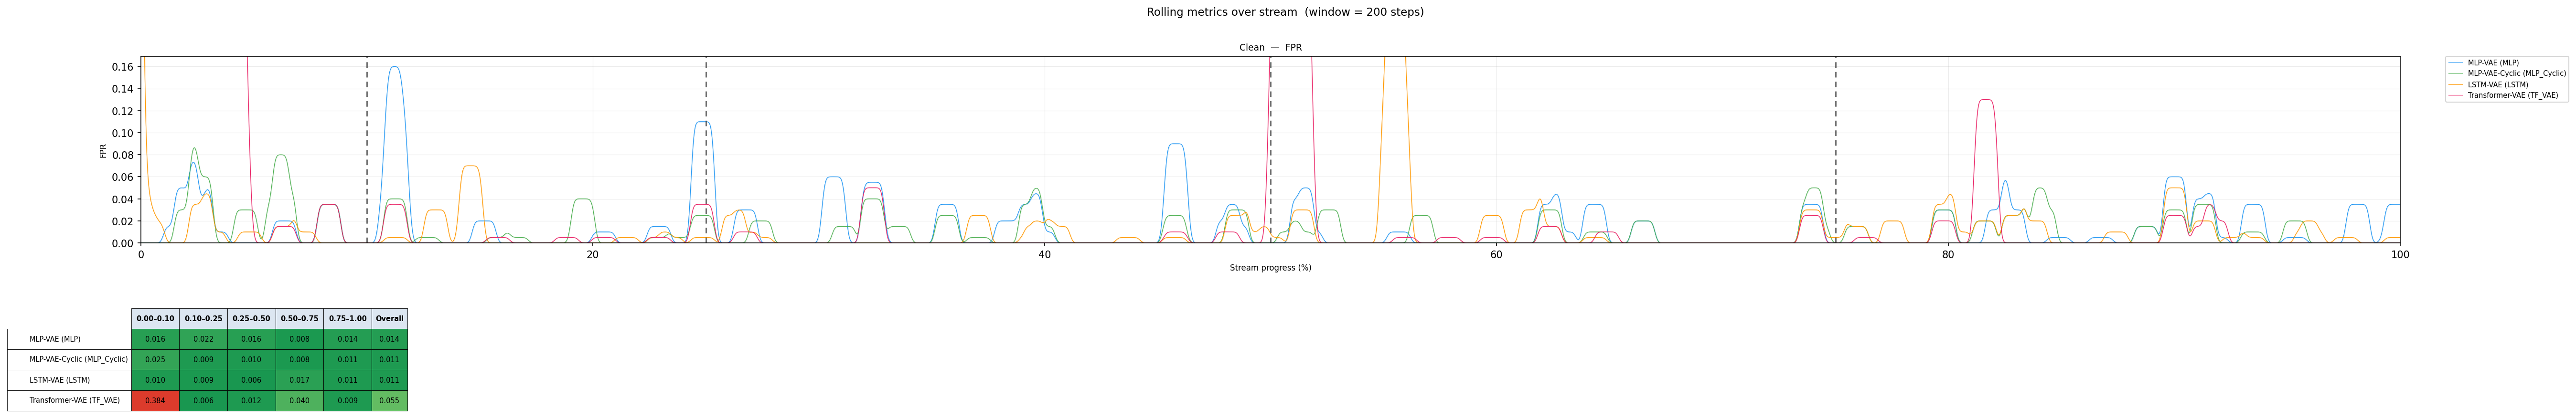

In [12]:
!python scripts/plot_fpr_over_time.py {OUTPUT_DIR}

from IPython.display import Image, display
display(Image(filename=f"{OUTPUT_DIR}/rolling_metrics.png"))

### Step 6 — Latent space: 3D UMAP colored by month

#### The plots above compare *behavior* (false positives). This one compares *representation* — how each architecture organizes clean weather data in its latent space, reduced to 3D via UMAP and colored by calendar month:

- a well-calibrated model's latent space should show smooth, continuous structure across months (clean data has no anomalies to separate out — only the seasonal cycle should be visible);
- sharp discontinuities or scattered, non-contiguous month clusters suggest the encoder is not capturing the underlying seasonal structure smoothly;
- this is an interactive 3D plot — drag to rotate, scroll to zoom, hover a point to see its month.

### Command:

In [13]:
import glob
from IPython.display import HTML, display

archs = [
    ("MLP", "MLP-VAE"),
    ("MLP_Cyclic", "MLP-VAE-Cyclic"),
    ("LSTM", "LSTM-VAE"),
    ("TF_VAE", "Transformer-VAE"),
]

for arch_dir, label in archs:
    matches = sorted(glob.glob(
        f"{OUTPUT_DIR}/**/{arch_dir}/**/latent_umap_month.html", recursive=True))
    print(f"{label} — latent space (3D UMAP, colored by month):")
    display(HTML(open(matches[0]).read()))

MLP-VAE — latent space (3D UMAP, colored by month):


MLP-VAE-Cyclic — latent space (3D UMAP, colored by month):


LSTM-VAE — latent space (3D UMAP, colored by month):


Transformer-VAE — latent space (3D UMAP, colored by month):


## Scope of this testcase

This notebook now runs on the same full-scale ERA5 export and warmup/test split as thesis_code's `q0_baseline/clean_baseline` experiment, so it is a much closer reproduction than the mini-dataset version — but it is still not a full reproduction of every result in the thesis: single seed, this repo's own port of the training code, and only the `Clean` anomaly type (no injected anomalies).

Differences from the exact thesis numbers are still possible. Conclusions should be based on the direction and consistency of the comparison across the four architectures rather than exact numerical agreement.

For the complete experiment definitions, consult the thesis sections associated with Fig 4.1, Fig 4.2, and Table 4.1, together with the YAML configuration files used by this suite. Requires the full-scale ERA5 source file locally (`data/era5/full_scale/`, gitignored — see `DATA_LICENSE.md`); not Colab-portable.